
--- After Example 1 (('Young', 'High', 'Graduate', 'Good') -> Yes) ---
S (Specific Boundary):
    ('Young', 'High', 'Graduate', 'Good')
G (General Boundary):
    ('?', '?', '?', '?')

--- After Example 2 (('Young', 'High', 'Graduate', 'Bad') -> Yes) ---
S (Specific Boundary):
    ('Young', 'High', 'Graduate', '?')
G (General Boundary):
    ('?', '?', '?', '?')

--- After Example 3 (('Middle', 'High', 'Graduate', 'Good') -> Yes) ---
S (Specific Boundary):
    ('?', 'High', 'Graduate', '?')
G (General Boundary):
    ('?', '?', '?', '?')

--- After Example 4 (('Old', 'Medium', 'Graduate', 'Good') -> Yes) ---
S (Specific Boundary):
    ('?', '?', 'Graduate', '?')
G (General Boundary):
    ('?', '?', '?', '?')

--- After Example 5 (('Old', 'Low', 'Undergrad', 'Good') -> No) ---
S (Specific Boundary):
    ('?', '?', 'Graduate', '?')
G (General Boundary):
    ('?', '?', 'Graduate', '?')

--- After Example 6 (('Old', 'Low', 'Undergrad', 'Bad') -> No) ---
S (Specific Boundary):
    ('?', '?', 

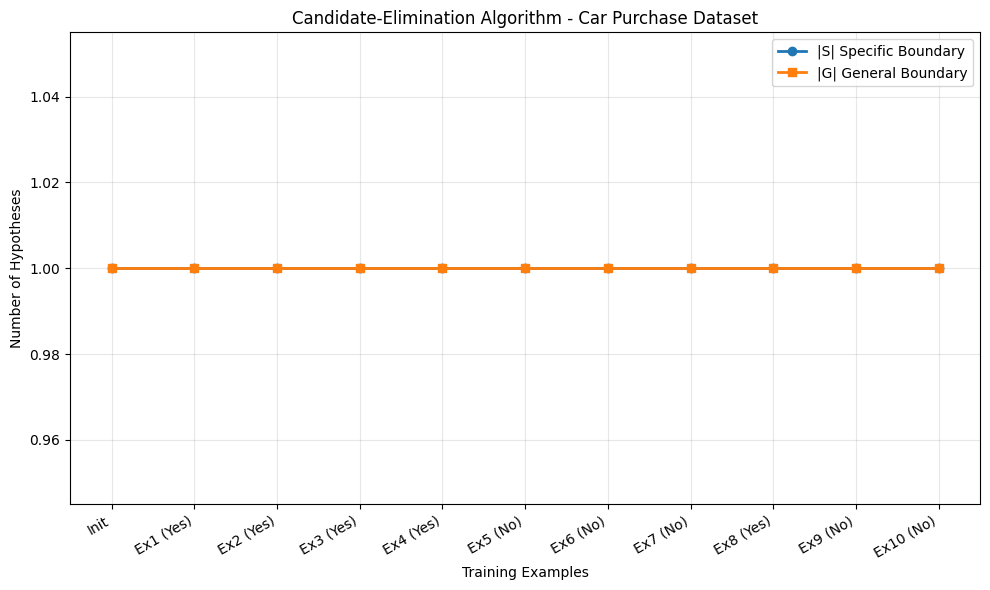

In [1]:

# CANDIDATE-ELIMINATION ALGORITHM
# Dataset: Car Purchase

import numpy as np
import matplotlib.pyplot as plt

#DATASET

# Attributes:
# Age, Income, Education, CreditScore

attributes = ['Age', 'Income', 'Education', 'CreditScore']

data = [
    ['Young',  'High',   'Graduate', 'Good', 'Yes'],
    ['Young',  'High',   'Graduate', 'Bad',  'Yes'],
    ['Middle', 'High',   'Graduate', 'Good', 'Yes'],
    ['Old',    'Medium', 'Graduate', 'Good', 'Yes'],
    ['Old',    'Low',    'Undergrad','Good', 'No'],
    ['Old',    'Low',    'Undergrad','Bad',  'No'],
    ['Middle', 'Low',    'Undergrad','Bad',  'No'],
    ['Young',  'Medium', 'Graduate', 'Good', 'Yes'],
    ['Young',  'Low',    'Undergrad','Good', 'No'],
    ['Old',    'Medium', 'Undergrad','Good', 'No'],
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)

# HELPER FUNCTIONS

def more_general(h1, h2):
    """Return True if h1 is more general than or equal to h2."""

    for x, y_ in zip(h1, h2):

        if x == '?':
            continue

        if x == '0':
            return False

        if x != y_ and y_ != '0':
            return False

    return True


def consistent(h, instance):
    """Check whether hypothesis h matches instance."""

    for hx, ix in zip(h, instance):

        if hx == '?':
            continue

        if hx != ix:
            return False

    return True


def min_generalizations(h, instance):
    """Return minimal generalizations of h."""

    new_h = list(h)

    for i in range(len(h)):

        if h[i] == '0':
            new_h[i] = instance[i]

        elif h[i] != instance[i]:
            new_h[i] = '?'

    return [tuple(new_h)]


def min_specializations(h, domains, instance):
    """Return minimal specializations of h."""

    results = []

    for i in range(len(h)):

        if h[i] == '?':

            for val in domains[i]:

                if val != instance[i]:

                    new_h = list(h)
                    new_h[i] = val
                    results.append(tuple(new_h))

        elif h[i] != '0':

            new_h = list(h)
            new_h[i] = '0'
            results.append(tuple(new_h))

    return results


def remove_more_general(hyps):
    """Remove hypotheses that are more general than another."""

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h2, h)
            for h2 in hyps
        )
    ]


def remove_less_general(hyps):
    """Remove hypotheses that are less general than another."""

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h, h2)
            for h2 in hyps
        )
    ]


# CANDIDATE-ELIMINATION ALGORITHM


def candidate_elimination(X, y, attributes):

    # Find possible values for each attribute
    domains = [
        sorted(set(row[i] for row in X))
        for i in range(len(attributes))
    ]

    # Initial Specific Boundary
    S = [tuple(['0'] * n_attributes)]

    # Initial General Boundary
    G = [tuple(['?'] * n_attributes)]

    # Store history
    history = {
        'S_sizes': [len(S)],
        'G_sizes': [len(G)],
        'S_sets': [list(S)],
        'G_sets': [list(G)],
        'labels': ['Init']
    }

    # Process each training example
    for idx, (instance, label) in enumerate(zip(X, y)):

        instance = tuple(instance)

        # POSITIVE EXAMPLE

        if label == 'Yes':

            # Remove inconsistent hypotheses from G
            G = [
                g for g in G
                if consistent(g, instance)
            ]

            new_S = []

            for s in S:

                if consistent(s, instance):

                    new_S.append(s)

                else:

                    generalizations = min_generalizations(
                        s, instance
                    )

                    for h in generalizations:

                        if any(
                            more_general(g, h)
                            for g in G
                        ):
                            new_S.append(h)

            S = remove_more_general(
                list(set(new_S))
            )

        # NEGATIVE EXAMPLE

        else:

            # Remove hypotheses from S
            S = [
                s for s in S
                if not consistent(s, instance)
            ]

            new_G = []

            for g in G:

                if not consistent(g, instance):

                    new_G.append(g)

                else:

                    specializations = min_specializations(
                        g, domains, instance
                    )

                    for h in specializations:

                        if any(
                            more_general(h, s)
                            for s in S
                        ):
                            new_G.append(h)

            G = remove_less_general(
                list(set(new_G))
            )

        # Save history
        history['S_sizes'].append(len(S))
        history['G_sizes'].append(len(G))
        history['S_sets'].append(list(S))
        history['G_sets'].append(list(G))
        history['labels'].append(
            f'Ex{idx + 1} ({label})'
        )

        # Display intermediate result
        print(
            f"\n--- After Example {idx + 1} "
            f"({instance} -> {label}) ---"
        )

        print("S (Specific Boundary):")

        for s in S:
            print("   ", s)

        print("G (General Boundary):")

        for g in G:
            print("   ", g)

    return S, G, history


# RUN ALGORITHM

S_final, G_final, history = candidate_elimination(
    X, y, attributes
)


# FINAL RESULT

print("\n====================================")
print("FINAL SPECIFIC BOUNDARY (S):")
print("====================================")

for s in S_final:
    print("  ", s)

print("\n====================================")
print("FINAL GENERAL BOUNDARY (G):")
print("====================================")

for g in G_final:
    print("  ", g)


# VISUALIZATION

steps = range(len(history['S_sizes']))

plt.figure(figsize=(10, 6))

plt.plot(
    steps,
    history['S_sizes'],
    marker='o',
    linewidth=2,
    label='|S| Specific Boundary'
)

plt.plot(
    steps,
    history['G_sizes'],
    marker='s',
    linewidth=2,
    label='|G| General Boundary'
)

plt.xticks(
    steps,
    history['labels'],
    rotation=30,
    ha='right'
)

plt.xlabel("Training Examples")
plt.ylabel("Number of Hypotheses")

plt.title(
    "Candidate-Elimination Algorithm - Car Purchase Dataset"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()